# TC 5033
## Deep Learning
## Fully Connected Deep Neural Networks

#### Activity 1b: Implementing a Fully Connected Network for Kaggle ASL Dataset

- Objective

The aim of this part of the activity is to apply your understanding of Fully Connected Networks by implementing a multilayer network for the [Kaggle ASL (American Sign Language) dataset](https://www.kaggle.com/datasets/grassknoted/asl-alphabet). While you have been provided with a complete solution for a Fully Connected Network using Numpy for the MNIST dataset, you are encouraged to try to come up with the solution.

- Instructions

    This activity requires submission in teams of 3 or 4 members. Submissions from smaller or larger teams will not be accepted unless prior approval has been granted (only due to exceptional circumstances). While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Load and Preprocess Data: You are provided a starter code to load the data. Be sure to understand the code.

    Review MNIST Notebook (Optional): Before diving into this activity, you have the option to revisit the MNIST example to refresh your understanding of how to build a Fully Connected Network using Numpy.

    Start Fresh: Although you can refer to the MNIST solution at any point, try to implement the network for the ASL dataset on your own. This will reinforce your learning and understanding of the architecture and mathematics involved.

    Implement Forward and Backward Pass: Write the code to perform the forward and backward passes, keeping in mind the specific challenges and characteristics of the ASL dataset.
    
     Design the Network: Create the architecture of the Fully Connected Network tailored for the ASL dataset. Choose the number of hidden layers, neurons, and hyperparameters judiciously.

    Train the Model: Execute the training loop, ensuring to track performance metrics such as loss and accuracy.

    Analyze and Document: Use Markdown cells to document in detail the choices you made in terms of architecture and hyperparameters, you may use figures, equations, etc to aid in your explanations. Include any metrics that help justify these choices and discuss the model's performance.  

- Evaluation Criteria

    - Code Readability and Comments
    - Appropriateness of chosen architecture and hyperparameters for the ASL dataset
    - Performance of the model on the ASL dataset (at least 70% acc)
    - Quality of Markdown documentation

- Submission

Submit this Jupyter Notebook in canvas with your complete solution, ensuring your code is well-commented and includes Markdown cells that explain your design choices, results, and any challenges you encountered.


In [1]:
import numpy as np
import string
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import os

%load_ext autoreload
%autoreload 2
#################################
%matplotlib inline


In [2]:
# DATA_PATH = '/media/pepe/DataUbuntu/Databases/asl_data/'
DATA_PATH = './asl_data'
train_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_train.csv'))
valid_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_valid.csv'))

In [3]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
train_df.shape

(27455, 785)

### Importar Images

In [5]:
y_train = np.array(train_df['label'])
y_val = np.array(valid_df['label'])
del train_df['label']
del valid_df['label']
x_train = train_df.values.astype(np.float32)
x_val = valid_df.values.astype(np.float32)

In [6]:
def split_val_test(x, y, pct=0.5, shuffle=True):
    '''
    Splits the given dataset into validation and test sets.

    Parameters:
        x (np.ndarray): Feature data to split.
        y (np.ndarray): Corresponding labels.
        pct (float): Proportion of data to assign to the validation set (default 0.5).
        shuffle (bool): Whether to shuffle the data before splitting (default True).

    Returns:
        x_val (np.ndarray): Validation features.
        y_val (np.ndarray): Validation labels.
        x_test (np.ndarray): Test features.
        y_test (np.ndarray): Test labels.
    '''
    n = len(x)  # Total number of samples
    idxs = np.arange(n)  # Create array of indices
    if shuffle:
        np.random.shuffle(idxs)  # Shuffle indices if required
    split = int(n * pct)  # Calculate split point for validation set
    val_idx, test_idx = idxs[:split], idxs[split:]  # Split indices
    x_val, y_val = x[val_idx], y[val_idx]           # Validation set
    x_test, y_test = x[test_idx], y[test_idx]        # Test set
    return x_val, y_val, x_test, y_test

In [7]:
# Split the current validation set into a new validation set and a test set (50% each)
# This helps to have separate data for validation during training and for final testing
x_val, y_val, x_test, y_test = split_val_test(x_val, y_val)

In [8]:
### The following

alphabet=list(string.ascii_lowercase)
alphabet.remove('j')
alphabet.remove('z')
print(len(alphabet))

24


### Normalise

In [9]:
# Calculate and display the mean, standard deviation, and minimum value of the training data
x_train.mean(), x_train.std(), x_train.min()

(np.float32(159.29102), np.float32(48.769505), np.float32(0.0))

In [10]:
def normalise(x_mean, x_std, x_data):
    """
    Normalizes the input data using the provided mean and standard deviation.

    Parameters:
        x_mean (float): Mean value of the training data.
        x_std (float): Standard deviation of the training data.
        x_data (np.ndarray): Data to be normalized.

    Returns:
        np.ndarray: Normalized data.
    """
    return (x_data - x_mean) / x_std

In [11]:
# Calculate the mean and standard deviation of the training data
x_mean = x_train.mean()
x_std = x_train.std()

# Normalize the training, validation, and test sets using the training mean and std
x_train_norm = normalise(x_mean, x_std, x_train)
x_val_norm = normalise(x_mean, x_std, x_val)
x_test_norm = normalise(x_mean, x_std, x_test)

### Graficar muestras

In [12]:
def plot_image(image):
    """
    Plots a single grayscale image using matplotlib.

    Parameters:
        image (np.ndarray): 2D array representing the image to plot.

    Returns:
        None
    """
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

La imagen corresponde al simbolo #: 0 que es la letra: a


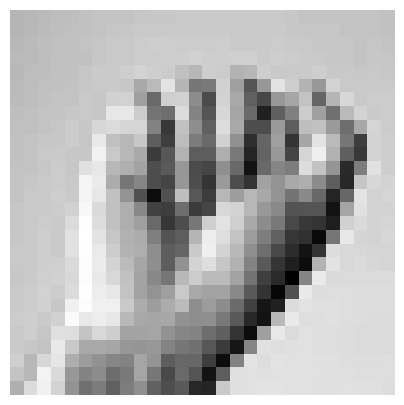

In [29]:
# Select a random index from the test set
rnd_idx = np.random.randint(len(y_test))

# Print the label index and corresponding letter for the selected image
print(f'La imagen corresponde al simbolo #: {y_test[rnd_idx]}', 
    f'que es la letra: {alphabet[y_test[rnd_idx]]}')

# Plot the selected image reshaped to 28x28 pixels
plot_image(x_test[rnd_idx].reshape(28, 28))

### Ecuaciones para nuestro modelo


$$z^1 = W^1 X + b^1$$

$$a^1 = ReLU(z^1) $$

$$z^2 = W^2 a^1 + b^2$$

$$\hat{y} = \frac{e^{z^{2_k}}}{\sum_j{e^{z_j}}}$$


$$ \mathcal{L}(\hat{y}^{i}, y^{i}) =  - y^{i}  \ln(\hat{y}^{i}) = -\ln(\hat{y}^i)$$


$$ \mathcal{J}(w, b) =  \frac{1}{num\_samples} \sum_{i=1}^{num\_samples}-\ln(\hat{y}^{i})$$

### Funciones adicionales

#### Mini batches

In [14]:
def create_minibatches(mb_size, x, y, shuffle=True):
    """
    Generates mini-batches from the given data.

    Parameters:
        mb_size (int): Size of each mini-batch.
        x (np.ndarray): Feature data of shape (num_samples, num_features).
        y (np.ndarray): Labels of shape (num_samples,) or (num_samples, 1).
        shuffle (bool): Whether to shuffle the data before splitting into batches (default True).

    Returns:
        generator: Yields tuples (x_batch, y_batch) for each mini-batch.
    """
    assert x.shape[0] == y.shape[0], 'Error en cantidad de muestras'
    total_data = x.shape[0]
    if shuffle: 
        idxs = np.arange(total_data)
        np.random.shuffle(idxs)
        x = x[idxs]
        y = y[idxs]  
    return ((x[i:i+mb_size], y[i:i+mb_size]) for i in range(0, total_data, mb_size))

## Nuestra clase Linear, ReLU y Sequential

In [15]:
# Define a custom numpy ndarray subclass for tensor operations
class np_tensor(np.ndarray): 
    pass

###  Clase Linear

In [16]:
class Linear():
    def __init__(self, input_size, output_size):
        '''
        Linear (fully connected) layer.

        Parameters:
            input_size (int): Number of input features.
            output_size (int): Number of output features.

        Initializes weights (W) using Kaiming He initialization and biases (b) as zeros.
        '''
        # Kaiming He initialization for weights
        self.W = (np.random.randn(output_size, input_size) / np.sqrt(input_size/2)).view(np_tensor)
        # Bias initialized to zeros
        self.b = (np.zeros((output_size, 1))).view(np_tensor)

    def __call__(self, X):
        '''
        Forward pass for the linear layer.

        Parameters:
            X (np.ndarray): Input data of shape (input_size, batch_size).

        Returns:
            Z (np.ndarray): Output of the linear transformation.
        '''
        Z = self.W @ X + self.b
        return Z

    def backward(self, X, Z):
        '''
        Backward pass for the linear layer. Computes gradients for weights, biases, and input.

        Parameters:
            X (np.ndarray): Input to the layer during the forward pass.
            Z (np.ndarray): Output from the forward pass, with Z.grad set externally.

        Sets:
            X.grad: Gradient of the loss with respect to X.
            self.W.grad: Gradient of the loss with respect to W.
            self.b.grad: Gradient of the loss with respect to b.
        '''
        # Gradient with respect to input X
        X.grad = self.W.T @ Z.grad
        # Gradient with respect to weights W
        self.W.grad = Z.grad @ X.T
        # Gradient with respect to biases b
        self.b.grad = np.sum(Z.grad, axis=1, keepdims=True)

### Clase ReLU

In [17]:
class ReLU():
    """
    ReLU (Rectified Linear Unit) activation layer.

    Applies the element-wise function: ReLU(x) = max(0, x)
    during the forward pass, and computes the gradient for
    the backward pass.
    """
    def __call__(self, Z):
        """
        Forward pass for the ReLU activation.

        Parameters:
            Z (np.ndarray): Input array.

        Returns:
            np.ndarray: Output after applying ReLU element-wise.
        """
        return np.maximum(0, Z)

    def backward(self, Z, A):
        """
        Backward pass for the ReLU activation.

        Parameters:
            Z (np.ndarray): Input to the layer during the forward pass.
            A (np.ndarray): Output from the forward pass, with A.grad set externally.

        Sets:
            Z.grad: Gradient of the loss with respect to Z.
        """
        Z.grad = A.grad.copy()          # Copy the gradient from the next layer
        Z.grad[Z <= 0] = 0              # Zero out gradients where Z was not positive

### Clase Sequential

In [18]:
class Sequential_layers():
    """
    Implements a simple sequential container for stacking layers (Linear, ReLU, etc.)
    and managing forward and backward passes for a fully connected neural network.
    """
    def __init__(self, layers):
        """
        Initializes the Sequential_layers object.

        Parameters:
            layers (list): List of layer objects (e.g., Linear, ReLU) in the desired order.
        """
        self.layers = layers
        self.x = None  # Stores the input to the network
        self.outputs = {}  # Stores outputs of each layer for use in backpropagation

    def __call__(self, X):
        """
        Performs the forward pass through all layers.

        Parameters:
            X (np.ndarray): Input data of shape (input_size, batch_size).

        Returns:
            np.ndarray: Output of the final layer.
        """
        self.x = X
        self.outputs['l0'] = self.x  # Store input as output of layer 0
        for i, layer in enumerate(self.layers, 1):
            self.x = layer(self.x)  # Forward pass through each layer
            self.outputs['l'+str(i)] = self.x  # Store output for each layer
        return self.x

    def backward(self):
        """
        Performs the backward pass through all layers in reverse order.
        Uses stored outputs for gradient computation.
        """
        for i in reversed(range(len(self.layers))):
            # Call backward for each layer, passing input and output of the layer
            self.layers[i].backward(self.outputs['l'+str(i)], self.outputs['l'+str(i+1)])

    def update(self, learning_rate=1e-3):
        """
        Updates the weights and biases of all Linear layers using computed gradients.

        Parameters:
            learning_rate (float): Learning rate for parameter update.
        """
        for layer in self.layers:
            if isinstance(layer, ReLU):
                continue  # ReLU has no parameters to update
            # Gradient descent update for weights and biases
            layer.W = layer.W - learning_rate * layer.W.grad
            layer.b = layer.b - learning_rate * layer.b.grad

    def predict(self, X):
        """
        Predicts the class label for the given input.

        Parameters:
            X (np.ndarray): Input data of shape (input_size, batch_size).

        Returns:
            int: Predicted class label (index of max output).
        """
        return np.argmax(self.__call__(X))    

### Cost Function

In [19]:
def softmaxXEntropy(x, y):
    """
    Computes the softmax probabilities and cross-entropy loss for a batch of predictions,
    and calculates the gradient of the loss with respect to the input logits.

    Parameters:
        x (np.ndarray): Logits array of shape (num_classes, batch_size).
        y (np.ndarray): Ground truth labels of shape (batch_size,) or (batch_size, 1).

    Returns:
        preds (np.ndarray): Softmax probabilities of shape (num_classes, batch_size).
        cost (float): Mean cross-entropy loss for the batch.

    Side effects:
        Sets x.grad to the gradient of the loss with respect to x.
    """
    batch_size = x.shape[1]
    exp_scores = np.exp(x)  # Exponentiate logits for softmax
    probs = exp_scores / exp_scores.sum(axis=0)  # Softmax probabilities
    preds = probs.copy()  # Store probabilities for output

    # Compute the probabilities corresponding to the correct classes
    y_hat = probs[y.squeeze(), np.arange(batch_size)]
    # Compute mean cross-entropy loss
    cost = np.sum(-np.log(y_hat)) / batch_size

    # Compute gradient of loss w.r.t. logits (softmax + cross-entropy derivative)
    probs[y.squeeze(), np.arange(batch_size)] -= 1  # dL/dx
    x.grad = probs.copy()

    return preds, cost

### Loop de entrenamiento

In [20]:
def accuracy(x, y, mb_size):
    """
    Computes the accuracy of the model on the given dataset.

    Parameters:
        x (np.ndarray): Feature data of shape (num_samples, num_features).
        y (np.ndarray): True labels of shape (num_samples,) or (num_samples, 1).
        mb_size (int): Mini-batch size.

    Returns:
        float: Accuracy as the proportion of correct predictions.
    """
    correct = 0  # Counter for correct predictions
    total = 0    # Counter for total samples
    # Iterate over mini-batches
    for i, (x_batch, y_batch) in enumerate(create_minibatches(mb_size, x, y)):
        # Forward pass: get model predictions for the batch
        pred = model(x_batch.T.view(np_tensor))
        # Count correct predictions in the batch
        correct += np.sum(np.argmax(pred, axis=0) == y_batch.squeeze())
        # Update total number of samples processed
        total += pred.shape[1]
    # Return accuracy as correct predictions divided by total samples
    return correct / total

In [21]:
def train(model, epochs, x_train, y_train, x_val, y_val, mb_size=128, learning_rate=1e-3):
    """
    Trains the given model using mini-batch gradient descent.

    Parameters:
        model (Sequential_layers): The neural network model to train.
        epochs (int): Number of epochs to train for.
        x_train (np.ndarray): Training features, shape (num_samples, num_features).
        y_train (np.ndarray): Training labels, shape (num_samples,).
        x_val (np.ndarray): Validation features, shape (num_samples, num_features).
        y_val (np.ndarray): Validation labels, shape (num_samples,).
        mb_size (int): Mini-batch size.
        learning_rate (float): Learning rate for parameter updates.

    Prints:
        Cost and validation accuracy after each epoch.
    """
    for epoch in range(epochs):
        # Iterate over mini-batches
        for i, (x, y) in enumerate(create_minibatches(mb_size, x_train, y_train)):
            # Forward pass: compute model predictions (logits)
            scores = model(x.T.view(np_tensor))
            # Compute softmax probabilities and cross-entropy loss
            _, cost = softmaxXEntropy(scores, y)
            # Backward pass: compute gradients
            model.backward()
            # Update model parameters
            model.update(learning_rate)
        # Print epoch cost and validation accuracy
        print(f'Epoch {epoch + 1}, cost: {cost}, accuracy: {accuracy(x_val, y_val, mb_size)}')

### Create your model and train it

In [22]:
# Define the model architecture and training hyperparameters

# Create a fully connected neural network using Sequential_layers
# The architecture is:
# - Linear layer: input 784 (28x28 image), output 300 neurons
# - ReLU activation
# - Linear layer: input 300, output 200 neurons
# - ReLU activation
# - Linear layer: input 200, output 24 (number of ASL classes)
model = Sequential_layers([
    Linear(784, 300),  # First hidden layer with 300 neurons
    ReLU(),            # Activation function
    Linear(300, 200),  # Second hidden layer with 200 neurons
    ReLU(),            # Activation function
    Linear(200, 24)    # Output layer with 24 classes (ASL letters)
])

# Set mini-batch size for training
mb_size = 512

# Set learning rate for gradient descent
learning_rate = 5e-4

# Set number of training epochs
epochs = 30

In [23]:
# Train the model using the training loop
# This will fit the model on the normalized training data and evaluate on the normalized validation set

# Arguments:
# - model: the Sequential_layers neural network defined above
# - epochs: number of training epochs (set above)
# - x_train_norm: normalized training features
# - y_train: training labels
# - x_val_norm: normalized validation features
# - y_val: validation labels
# - mb_size: mini-batch size (set above)
# - learning_rate: learning rate for gradient descent (set above)

train(
    model, 
    epochs, 
    x_train_norm, 
    y_train, 
    x_val_norm, 
    y_val, 
    mb_size=mb_size, 
    learning_rate=learning_rate
)

Epoch 1, cost: 0.22556532392058315, accuracy: 0.771611823759063
Epoch 2, cost: 0.0536569624192372, accuracy: 0.7900167317345231
Epoch 3, cost: 0.024349142431054373, accuracy: 0.7914110429447853
Epoch 4, cost: 0.014656080931288139, accuracy: 0.7955939765755716
Epoch 5, cost: 0.011446547939373268, accuracy: 0.7992191857222533
Epoch 6, cost: 0.010319930481910192, accuracy: 0.7967094255437813
Epoch 7, cost: 0.006592363941062891, accuracy: 0.8000557724484105
Epoch 8, cost: 0.006211823750534082, accuracy: 0.7992191857222533
Epoch 9, cost: 0.004846038148099079, accuracy: 0.8025655326268823
Epoch 10, cost: 0.004298663330527462, accuracy: 0.8022866703848299
Epoch 11, cost: 0.004160197161776481, accuracy: 0.803680981595092
Epoch 12, cost: 0.0033538623988576747, accuracy: 0.8022866703848299
Epoch 13, cost: 0.003077355751651979, accuracy: 0.8022866703848299
Epoch 14, cost: 0.0028056288387381403, accuracy: 0.8039598438371445
Epoch 15, cost: 0.0022713259160064008, accuracy: 0.8031232571109872
Epoch 

### Test your model on Random data from your test set

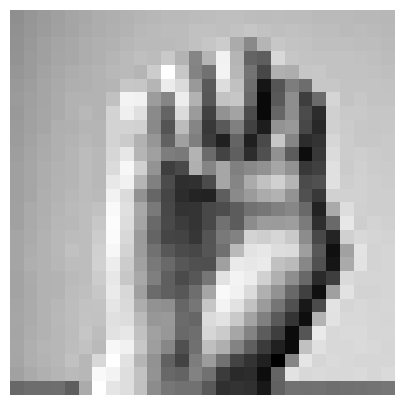

el valor predicho es: e el valor real es:e


In [25]:
# Select a random index from the test set
idx = np.random.randint(len(y_test))

# Plot the corresponding test image (reshaped to 28x28)
plot_image(x_test[idx].reshape(28, 28))

# Predict the class using the trained model
# The model expects input shape (features, 1), so reshape accordingly
pred = model.predict(x_test[idx].reshape(-1, 1))

# Print the predicted and actual class labels (as letters)
print(f'el valor predicho es: {alphabet[pred]} el valor real es:{alphabet[y_test[idx]]}')

## Final Conclusions and Comments